## Import des bibliothèques
Nous importons ici les outils nécessaires pour charger, nettoyer et manipuler les données du projet.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import networkx as nx

## fonction de load et de merge

In [3]:
Data_path = "datasets-project/datasets/"

def load_all_data():
    orders = pd.read_csv(Data_path + "orders.csv")
    products = pd.read_csv(Data_path + "products.csv", sep=",")
    order_products = pd.read_csv(Data_path + "order_products.csv", sep=",")
    aisles = pd.read_csv(Data_path + "aisles.csv", sep=",")
    departments = pd.read_csv(Data_path + "departments.csv", sep=",")

    return orders, products, aisles, departments, order_products

def merge_all(orders, products, aisles, departments, order_products):

    df = order_products.merge(orders, on="order_id", how="left")
    df = df.merge(products, on="product_id", how="left")
    df = df.merge(aisles, on="aisle_id", how="left")
    df = df.merge(departments, on="department_id", how="left")

    return df

## Chargement des données
Cette cellule charge les différents fichiers du projet afin de récupérer toutes les tables utiles à l’analyse.

In [4]:
orders, products, aisles, departments, order_products = load_all_data()

## Fusion des tables
Les données étant réparties dans plusieurs fichiers, nous les fusionnons ici pour obtenir un seul dataset complet.

In [5]:
df = merge_all(orders, products, aisles, departments, order_products)

## Vérification du chargement
Cette cellule permet de vérifier rapidement que les colonnes principales ont bien été chargées et correspondent au format attendu.

In [6]:
print("order_dow:", df["order_dow"].min(), df["order_dow"].max())
print("order_hour_of_day:", df["order_hour_of_day"].min(), df["order_hour_of_day"].max())

#poucentage de NaN
print("days_since_prior_order NaN%:", df["days_since_prior_order"].isna().mean())

order_dow: 0.0 6.0
order_hour_of_day: 0.0 23.0
days_since_prior_order NaN%: 0.06419340670768749


## Dimensions du dataset
Nous affichons ici la taille du dataset afin de connaître le nombre de lignes et de colonnes après la fusion.

In [126]:
#.shape affiche : (lignes, colonnes)
print(df.shape)

#.dtypes affiche le type de chaque colonne
df.dtypes

(13692886, 14)


order_id                    int64
product_id                float64
add_to_cart_order         float64
reordered                 float64
user_id                   float64
order_number              float64
order_dow                 float64
order_hour_of_day         float64
days_since_prior_order    float64
product_name               object
aisle_id                  float64
department_id             float64
aisle                      object
department                 object
dtype: object

## Vérification des valeurs manquantes
Nous identifions ici les colonnes contenant des valeurs manquantes afin de repérer les éventuels problèmes de qualité de données.

In [127]:
#calcul le nombre de True (NaN) et False(non NaN), en fait la somme et les trie du plus grand au plus petit
nulls = df.isna().sum().sort_values(ascending=False)

#affiche que les colonnes avec NaN car false sera toujours égal à 0
nulls[nulls > 0]

days_since_prior_order    878993
product_id                   449
aisle_id                     449
department_id                449
product_name                 449
reordered                    449
aisle                        449
department                   449
add_to_cart_order            446
user_id                      357
order_number                 244
order_dow                    203
order_hour_of_day            198
dtype: int64

## Vérification des doublons
Cette étape permet de vérifier si certaines lignes apparaissent plusieurs fois dans le dataset.

In [128]:
df.duplicated().sum()

np.int64(0)

## Contrôle des jours de commande
Nous vérifions que la colonne représentant le jour de commande contient bien des valeurs cohérentes.

In [129]:
df["order_dow"].min(), df["order_dow"].max()

(np.float64(0.0), np.float64(6.0))

## Contrôle du numéro de commande
Nous regardons ici les valeurs minimales et maximales du numéro de commande afin de vérifier sa cohérence.

In [130]:
df["order_number"].min(), df["order_number"].max()

(np.float64(1.0), np.float64(99.0))

## Contrôle des heures de commande
Nous vérifions ici que les heures de commande sont bien comprises dans une plage logique.

In [131]:
df["order_hour_of_day"].min(), df["order_hour_of_day"].max()

(np.float64(0.0), np.float64(23.0))

## Nettoyage du dataset
Dans cette cellule, nous corrigeons les valeurs manquantes et supprimons les colonnes ou lignes inutiles afin d’obtenir une base propre.

In [132]:
#.fillna remplace tous les NaN par 0( si un utilisateur fait sa première commande, cette colonne affiche NaN pour éviter une supression de ligne on replace NaN par 0)
df["days_since_prior_order"] = df["days_since_prior_order"].fillna(0)

#supression de toutes les lignes ayant un NaN
df = df.dropna(subset=[
    "order_id","product_id","user_id",
    "order_number","order_dow","order_hour_of_day",
    "add_to_cart_order","reordered",
    "aisle_id","department_id"
])

## Optimisation des types
Nous modifions ici le type de certaines colonnes afin de réduire la mémoire utilisée et d’améliorer les performances.

##### int8	1 octet	-128 → 127
##### int16	2 octets	-32 768 → 32 767
##### int32	4 octets	~ -2 milliards → +2 milliards
##### int64	8 octets	très très grand

In [133]:
#changement des types pour une optimisation de la mémoire
df["order_id"] = df["order_id"].astype("int32")
df["product_id"] = df["product_id"].astype("int32")
df["user_id"] = df["user_id"].astype("int32")

df["order_number"] = df["order_number"].astype("int16")
df["order_dow"] = df["order_dow"].astype("int8")
df["order_hour_of_day"] = df["order_hour_of_day"].astype("int8")

df["days_since_prior_order"] = df["days_since_prior_order"].astype("int16")
df["add_to_cart_order"] = df["add_to_cart_order"].astype("int16")
df["reordered"] = df["reordered"].astype("int8")

df["aisle"] = df["aisle"].astype("category")
df["department"] = df["department"].astype("category")

## Vérification après nettoyage
Cette cellule permet de confirmer que le dataset est maintenant propre, cohérent et prêt à être utilisé.

In [134]:
print("Shape:", df.shape)
print("Total NaN:", df.isna().sum().sum())
print("dow range:", df["order_dow"].min(), df["order_dow"].max())
print("hour range:", df["order_hour_of_day"].min(), df["order_hour_of_day"].max())
print("reordered unique:", df["reordered"].unique())
df.head()

Shape: (13690540, 14)
Total NaN: 0
dow range: 0 6
hour range: 0 23
reordered unique: [1 0]


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,3,5,9,8,Organic Egg Whites,86.0,16.0,eggs,dairy eggs
1,2,28985,2,1,202279,3,5,9,8,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce
2,2,9327,3,0,202279,3,5,9,8,Garlic Powder,104.0,13.0,spices seasonings,pantry
3,2,45918,4,1,202279,3,5,9,8,Coconut Butter,19.0,13.0,oils vinegars,pantry
4,2,30035,5,0,202279,3,5,9,8,Natural Sweetener,17.0,13.0,baking ingredients,pantry


## Unicité des commandes
Nous comparons ici le nombre de commandes uniques au nombre total de lignes afin de mieux comprendre la structure du dataset.

In [135]:
df["order_id"].nunique(), len(df["order_id"])

(1357445, 13690540)

## Taille moyenne des paniers
Cette cellule calcule le nombre moyen de produits présents dans une commande.

In [136]:
df.groupby("order_id")["product_id"].count().mean()

np.float64(10.085520960333568)

## Activité moyenne des clients
Nous mesurons ici combien de commandes un client passe en moyenne sur l’ensemble du dataset.

In [137]:
df.groupby("user_id")["order_number"].max().mean()

np.float64(14.921093833128126)

## Feature 1 — Total de commandes par utilisateur
Nous créons une variable indiquant combien de commandes chaque utilisateur a passées au total.

In [138]:
user_total_orders = df.groupby("user_id")["order_number"].max()
df["user_total_orders"] = df["user_id"].map(user_total_orders)

## Feature 2 — Historique d’achat utilisateur-produit
Cette variable permet de savoir combien de fois un utilisateur a déjà acheté un produit donné avant la ligne actuelle.

In [139]:
user_product_count = df.groupby(["user_id", "product_id"]).cumcount() #cumcount() sert a compter les lignes dans l'ordre d'apparition dans chaques groupe
df["user_product_purchase_count"] = user_product_count

## Feature 3 — Taux de réachat par produit
Nous calculons ici la fréquence moyenne de réachat de chaque produit afin de mesurer sa fidélité.

In [140]:
product_reorder_rate = df.groupby("product_id")["reordered"].mean()
df["product_reorder_rate"] = df["product_id"].map(product_reorder_rate) # le map sert a associer une valeurs a sa clé( si user 1 a acheté 3 fois des pommes chaques pomme aura 0.66 de reorder rate( la 1ere ne compte pas dans le lot))

## Feature 4 — Taille du panier
Cette variable indique combien de produits sont présents dans chaque commande.

In [141]:
order_size = df.groupby("order_id")["product_id"].count()
df["order_size"] = df["order_id"].map(order_size)

## Création du dataset final
Nous enregistrons ici la version nettoyée et enrichie du dataset qui sera utilisée pour la suite du projet.

In [142]:
clean_df = df

## Vérification du dataset final
Cette cellule permet de confirmer les dimensions finales du dataset après nettoyage et ajout des nouvelles variables.

In [143]:
print("Shape:", clean_df.shape)
print("Total NaN:", clean_df.isna().sum().sum())
clean_df.head()

Shape: (13690540, 18)
Total NaN: 0


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department,user_total_orders,user_product_purchase_count,product_reorder_rate,order_size
0,2,33120,1,1,202279,3,5,9,8,Organic Egg Whites,86.0,16.0,eggs,dairy eggs,7,0,0.706693,9
1,2,28985,2,1,202279,3,5,9,8,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce,7,0,0.696159,9
2,2,9327,3,0,202279,3,5,9,8,Garlic Powder,104.0,13.0,spices seasonings,pantry,7,0,0.152273,9
3,2,45918,4,1,202279,3,5,9,8,Coconut Butter,19.0,13.0,oils vinegars,pantry,7,0,0.278638,9
4,2,30035,5,0,202279,3,5,9,8,Natural Sweetener,17.0,13.0,baking ingredients,pantry,7,0,0.500000,9


## Schéma simplifié des données
Cette partie rappelle rapidement comment les différentes tables du projet sont liées entre elles.
```
orders (order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order)
        1
        │ (orders.order_id = order_products.order_id)
        ▼
order_products (order_id, product_id, add_to_cart_order, reordered)
        ▲
        │ (products.product_id = order_products.product_id)
        1
products (product_id, product_name, aisle_id)
        1
        │ (aisles.aisle_id = products.aisle_id)
        ▼
aisles (aisle_id, aisle, department_id)
        1
        │ (departments.department_id = aisles.department_id)
        ▼
departments (department_id, department)
```

Ordre de merge : order_products → orders → products → aisles → departments

# EDA

## Paramètre d’analyse
Nous définissons ici le nombre d’éléments à afficher dans certaines analyses, afin de garder des résultats lisibles.

Quels produits sont les bestsellers (global et par département) ?

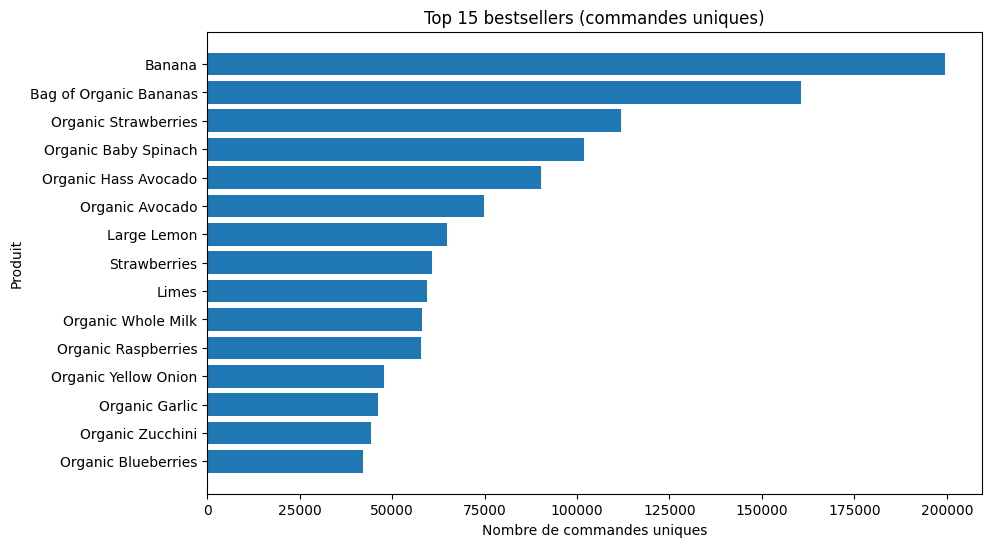

,product_name,order_id
0,Banana,199616
1,Bag of Organic Bananas,160599
2,Organic Strawberries,111961
3,Organic Baby Spinach,101903
4,Organic Hass Avocado,90362
5,Organic Avocado,74947
6,Large Lemon,64855
7,Strawberries,60756
8,Limes,59290
9,Organic Whole Milk,58202


In [ ]:
top_n = 15
# nombre de produit qu'on veut afficher


# On crée un DataFrame contenant les produits les plus commandés
global_best = (
    clean_df    
    .groupby(["product_name"])["order_id"]
    #pour chaque produit on compte le nombre de commandes uniques
    .nunique()
    # on trie du plus grand au plus petit
    .sort_values(ascending=False)
    #on affiche que les top_n produits
    .head(top_n)
    # on remet le résultat sous forme de DataFrame
    .reset_index(name="order_id")
)

#On retrie dans l'ordre croissant pour un affichage plus lisible en barre horizontale
plot_df = global_best.sort_values("order_id", ascending=True)
# Permet de voir les premières lignes du DataFrame final
plot_df.head()
# Definition de la taille du graphique 
plt.figure(figsize=(10, 6))


# Création d'un graphique en barres horizontales
# Axe Y : nom du produit
# Axe X : nombre de commandes uniques
plt.barh(plot_df["product_name"], plot_df["order_id"])

# Ajout des labels et du titre
plt.xlabel("Nombre de commandes uniques")
plt.ylabel("Produit")
plt.title("Top 15 bestsellers (commandes uniques)")

# Affichage du graphique
plt.show()
global_best


## Bestsellers globaux et par département
Nous identifions ici les produits les plus vendus, à la fois sur l’ensemble du dataset et selon leur département.

/tmp/ipykernel_427402/1898791310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["department","aisle", "product_name"])["order_id"]
/tmp/ipykernel_427402/1898791310.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("department")


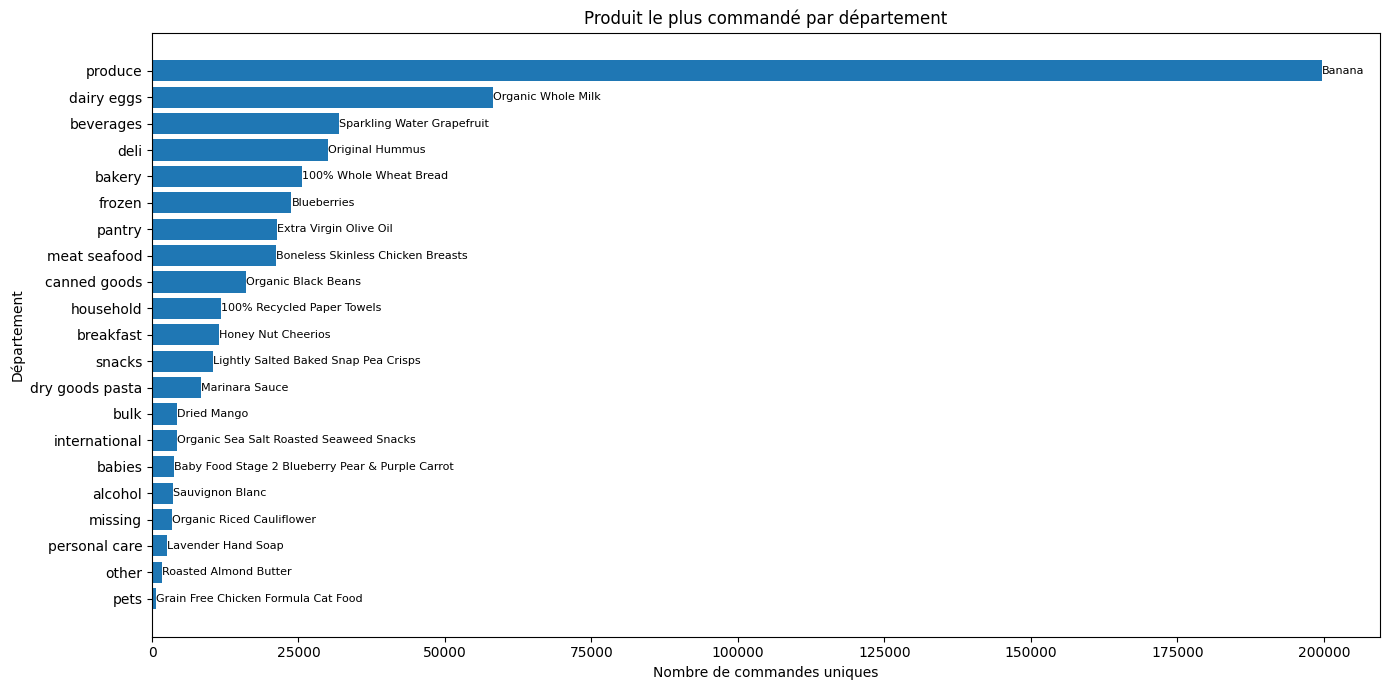

,department,aisle,product_name,order_id
6515657,alcohol,white wines,Sauvignon Blanc,3586
6774515,babies,baby food formula,Baby Food Stage 2 Blueberry Pear & Purple Carrot,3683
13690146,bakery,bread,100% Whole Wheat Bread,25556
26194091,beverages,water seltzer sparkling water,Sparkling Water Grapefruit,31996
27497538,breakfast,cereal,Honey Nut Cheerios,11464
33574919,bulk,bulk dried fruits vegetables,Dried Mango,4332
40508844,canned goods,canned meals beans,Organic Black Beans,16057
50129480,dairy eggs,milk,Organic Whole Milk,58202
55036726,deli,fresh dips tapenades,Original Hummus,30102
64105669,dry goods pasta,pasta sauce,Marinara Sauce,8352


In [ ]:
# On regroupe les données par département, rayon et nom de produit
# puis on compte le nombre de commandes uniques pour chaque produit

global_best_departement = (
    clean_df    
    .groupby(["department","aisle", "product_name"])["order_id"]
    .nunique()

    # on transforme le résultat en DataFrame
    .reset_index(name="order_id")

    # On trie par département puis par nombre de commandes décroissant
    # pour faire apparaître les produits les plus commandés en premier dans chaque département
    .sort_values(["department", "order_id"], ascending=[True, False])
    .groupby("department")
    .head(1)
)

plot_df = global_best_departement.sort_values("order_id", ascending=True)


plt.figure(figsize=(14, 7))

bars = plt.barh(plot_df["department"], plot_df["order_id"])

plt.xlabel("Nombre de commandes uniques")
plt.ylabel("Département")
plt.title("Produit le plus commandé par département")

# Parcourt chaque barre avec le nom du produit associé
for bar, product in zip(bars, plot_df["product_name"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        product,
        va="center",
        ha="left",
        fontsize=8
    )

# Ajuste automatiquement les espacements pour éviter que les éléments se chevauchent
plt.tight_layout()
plt.show()

global_best_departement

## Produits les plus fidèles
Cette analyse met en avant les produits ayant la plus forte probabilité d’être rachetés par les clients.

 Quels produits ont la plus forte probabilité de reorder (fidélité) ?


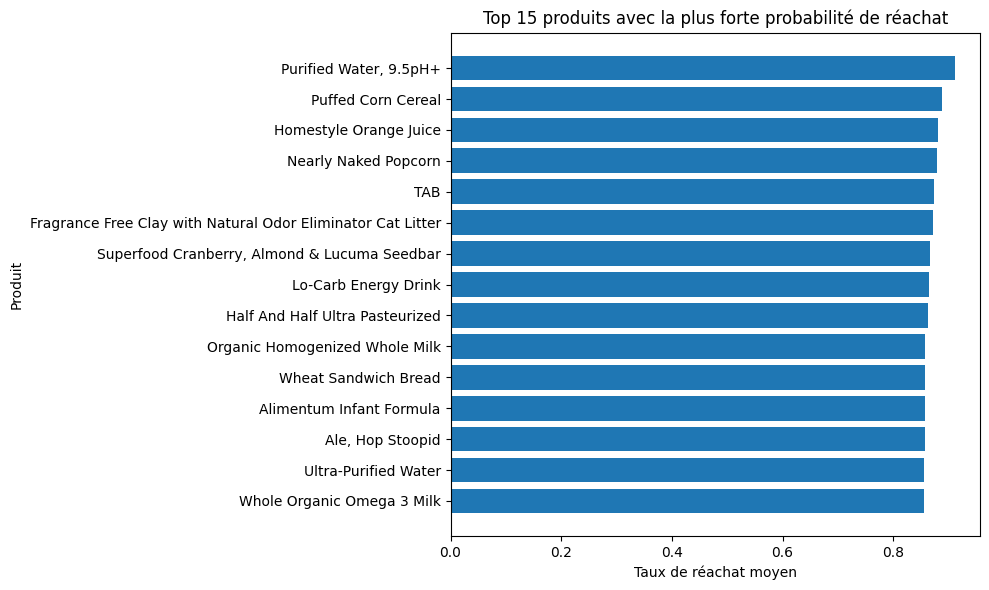

,product_id,product_name,reorder_rate,total_orders
47495,48095,"Purified Water, 9.5pH+",0.911290,124
13884,14067,Puffed Corn Cereal,0.887324,71
9907,10031,Homestyle Orange Juice,0.881481,135
35394,35829,Nearly Naked Popcorn,0.879310,58
6133,6209,TAB,0.873016,63
10109,10236,Fragrance Free Clay with Natural Odor Eliminat...,0.872727,55
14847,15041,"Superfood Cranberry, Almond & Lucuma Seedbar",0.865672,67
17250,17469,Lo-Carb Energy Drink,0.864253,221
9175,9292,Half And Half Ultra Pasteurized,0.862745,1224
5445,5514,Organic Homogenized Whole Milk,0.858186,1643


In [ ]:
# Regroupe les données par produit (id + nom)

reorder_probability = (
    clean_df
    .groupby(["product_id", "product_name"], as_index=False)
    .agg(
        reorder_rate=("reordered", "mean"),
        total_orders=("order_id", "nunique")
    )
    .query("total_orders >= 50")
    .sort_values("reorder_rate", ascending=False)
)

# Sélectionne les top_n produits les plus souvent rachetés
# puis les retrie dans l'ordre croissant pour un affichage plus lisible en barres horizontales
plot_df = (
    reorder_probability
    .head(top_n)
    .sort_values("reorder_rate", ascending=True)
)

plt.figure(figsize=(10, 6))
# Crée un graphique en barres horizontales
plt.barh(plot_df["product_name"], plot_df["reorder_rate"])
plt.xlabel("Taux de réachat moyen")
plt.ylabel("Produit")
plt.title(f"Top {top_n} produits avec la plus forte probabilité de réachat")
# Ajuste automatiquement les marges pour éviter les chevauchements
plt.tight_layout()
plt.show()

reorder_probability.head(top_n)




## Répartition des commandes dans le temps
Nous analysons ici les moments où les commandes sont le plus souvent passées.

Quand les commandes sont passé ?

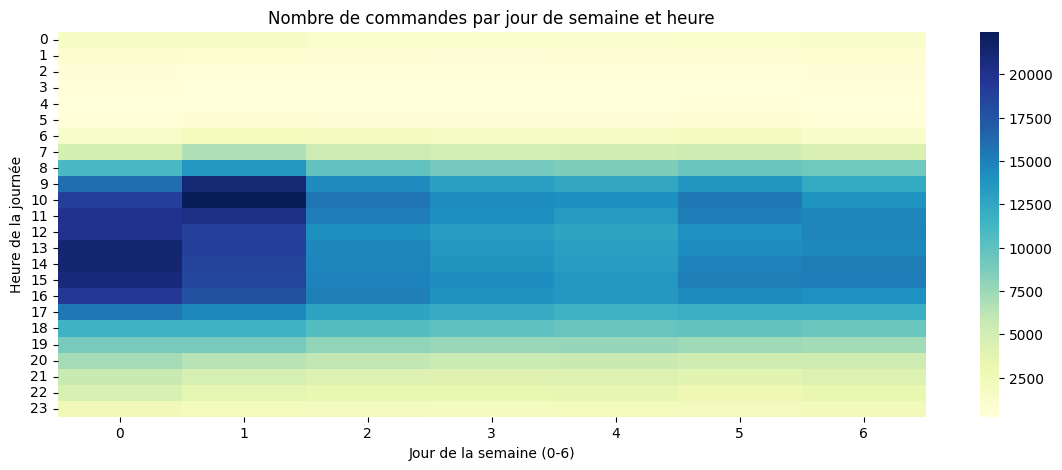

,order_dow,order_hour_of_day,total_orders
0,0,0,1510
1,0,1,923
2,0,2,543
3,0,3,378
4,0,4,316
...,...,...,...
163,6,19,7208
164,6,20,5268
165,6,21,4167
166,6,22,3304


In [ ]:
# Regroupe les données par jour de la semaine et par heure de la journée
# puis compte le nombre de commandes uniques pour chaque combinaison

command_passe = (
    clean_df
    .groupby(["order_dow", "order_hour_of_day"])["order_id"]
    .nunique()
    .reset_index(name="total_orders")
    .sort_values(["order_dow", "order_hour_of_day"], ascending=[True, True])
)
# Transforme le tableau en format matrice pour pouvoir créer une heatmap
heatmap_data = command_passe.pivot(
    index="order_hour_of_day",
    columns="order_dow",
    values="total_orders"
)

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Nombre de commandes par jour de semaine et heure")
plt.xlabel("Jour de la semaine (0-6)")
plt.ylabel("Heure de la journée")

plt.show()

command_passe


## Produit le plus souvent ajouté en premier
Cette cellule permet d’identifier les produits qui sont le plus souvent placés en tête du panier.

Produit le plus souvent ajouté en premier 

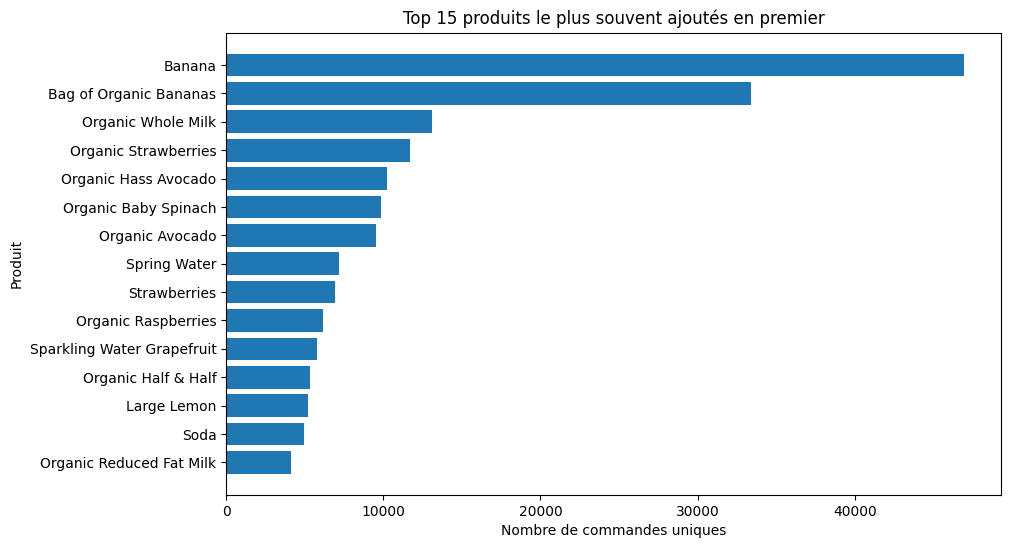

,product_id,product_name,total_orders
17931,24852,Banana,46964
9425,13176,Bag of Organic Bananas,33422
20098,27845,Organic Whole Milk,13118
15205,21137,Organic Strawberries,11672
34058,47209,Organic Hass Avocado,10210
15769,21903,Organic Baby Spinach,9832
34458,47766,Organic Avocado,9512
14133,19660,Spring Water,7157
12048,16797,Strawberries,6927
20187,27966,Organic Raspberries,6182


In [ ]:
# Sélectionne uniquement les produits ajoutés en première position dans le panier
# puis compte combien de commandes uniques contiennent ce produit en premier

first_product = (
    clean_df
    .query("add_to_cart_order == 1")
    .groupby(["product_id", "product_name"])["order_id"]
    .nunique()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False)
)
# Garde les top_n produits les plus souvent ajoutés en premier
# puis les trie dans l'ordre croissant pour un affichage plus lisible en barres horizontales
plot_df = (
    first_product
    .head(top_n)
    .sort_values("total_orders", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["product_name"], plot_df["total_orders"])
plt.xlabel("Nombre de commandes uniques")
plt.ylabel("Produit")
plt.title(f"Top {top_n} produits le plus souvent ajoutés en premier")
plt.show()

first_product.head(top_n)

## Préparation des paires de produits
Nous préparons ici les données nécessaires pour repérer les produits fréquemment achetés ensemble.

Paires de produits achetées ensemble

In [149]:
paire_produit = clean_df[["order_id", "product_id", "product_name"]]
paire_produit = paire_produit.merge(paire_produit, on="order_id")
paire_produit = paire_produit.query("product_id_x < product_id_y")
paire_produit = paire_produit.groupby(["product_name_x", "product_name_y", "product_id_x", "product_id_y"])["order_id"].nunique().reset_index(name="total_orders").sort_values("total_orders", ascending=False)

paire_produit

,product_name_x,product_name_y,product_id_x,product_id_y,total_orders
1531262,Bag of Organic Bananas,Organic Hass Avocado,13176,47209,26431
1532286,Bag of Organic Bananas,Organic Strawberries,13176,21137,26003
16142305,Organic Strawberries,Banana,21137,24852,23749
1669096,Banana,Organic Avocado,24852,47766,22770
13180212,Organic Baby Spinach,Banana,21903,24852,21551
...,...,...,...,...,...
24921557,with a Splash of Pineapple Coconut Water,Unsweetened Vanilla Almond Milk,2987,43295,1
24921556,with a Splash of Pineapple Coconut Water,Unsweetened Organic Ginger Oasis Tea,2987,39706,1
24921555,with a Splash of Pineapple Coconut Water,Ultra Thin Sliced Provolone Cheese,2987,22105,1
24921554,with a Splash of Pineapple Coconut Water,Ultra Strong Unscented 2-Ply Bathroom Tissue,2987,23234,1


## Produits achetés ensemble
Cette analyse met en évidence les associations de produits les plus fréquentes dans les commandes.

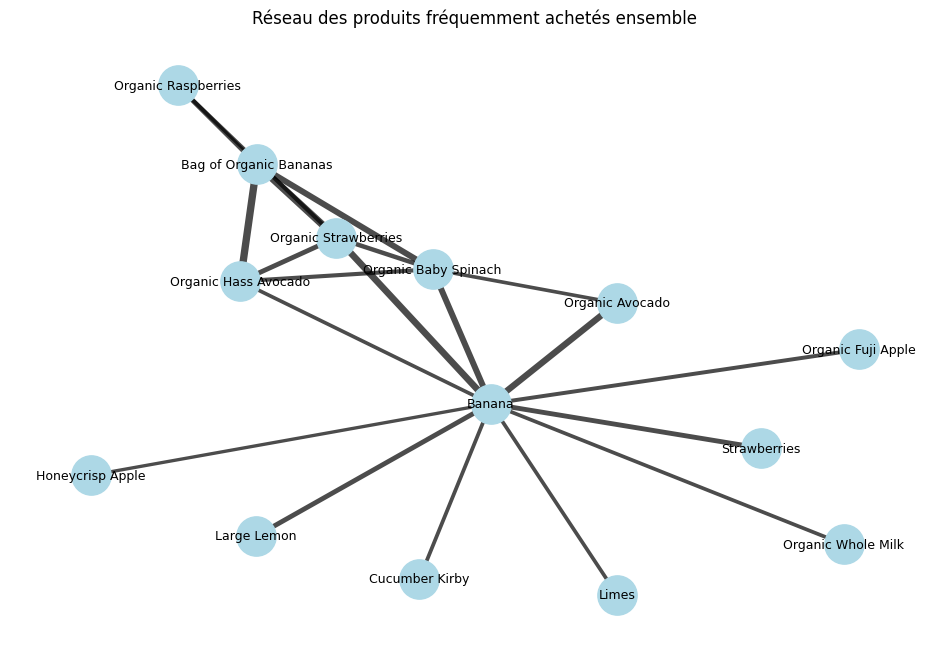

In [150]:
top_pairs = paire_produit.head(20)

Graph = nx.Graph()

# Ajout des liens entre produits
for _, row in top_pairs.iterrows():
    Graph.add_edge(
        row["product_name_x"],
        row["product_name_y"],
        weight=row["total_orders"]
    )

# Création de la position des noeuds
pos = nx.spring_layout(Graph, k=0.5, seed=42)

plt.figure(figsize=(12,8))

nx.draw_networkx_nodes(Graph, pos, node_size=800, node_color="lightblue")

# Dessin des liens (épaisseur selon fréquence)
weights = [Graph[u][v]["weight"]/5000 for u,v in Graph.edges()]
nx.draw_networkx_edges(Graph, pos, width=weights, alpha=0.7)

nx.draw_networkx_labels(Graph, pos, font_size=9)

plt.title("Réseau des produits fréquemment achetés ensemble")
plt.axis("off")
plt.show()


Ce graphique montre quels produits sont souvent achetés dans la même commande.

Chaque cercle représente un produit.  
Les lignes entre les produits indiquent qu’ils sont fréquemment achetés ensemble par les clients.

Par exemple, on peut voir que certains produits comme les bananes sont liés à beaucoup d’autres produits, ce qui signifie qu’ils apparaissent très souvent dans les paniers des clients.

## Produits à mettre en avant le samedi
Nous cherchons ici à identifier les produits particulièrement présents dans les commandes du samedi.

 Quels produits devraient être mis en avant le samedi 

In [ ]:
# Sélectionne uniquement les commandes passées le samedi (order_dow == 5)
# puis compte le nombre de commandes uniques pour chaque produit

saturday_orders = (
    clean_df    
    .query("order_dow == 5")
    .groupby(["product_name"])["order_id"]
    .nunique()
    .reset_index(name="saturday_orders")
    .sort_values("saturday_orders", ascending=False)
  
) 


# Sélectionne les commandes passées les autres jours de la semaine
# puis compte le nombre de commandes uniques pour chaque produit
other_day_orders = (
    clean_df   
    .query("order_dow != 5") 
    .groupby(["product_name"])["order_id"]
    .nunique()
    .reset_index(name="other_day_orders")
    .sort_values("other_day_orders", ascending=False)
  
)
# Fusionne les deux tableaux sur le nom du produit
# pour comparer les commandes du samedi avec celles des autres jours
analyse_samedi = saturday_orders.merge(other_day_orders, on="product_name", how="inner")
# on compare les commandes du samedi à la moyenne quotidienne des 6 autres jours
# si le score est > 1, le produit est relativement plus commandé le samedi
analyse_samedi["saturday_score"] = analyse_samedi["saturday_orders"] / (analyse_samedi["other_day_orders"] / 6)

# Garde seulement les produits ayant au moins 50 commandes le samedi
# pour éviter les résultats peu fiables sur des volumes trop faibles
analyse_samedi = analyse_samedi[analyse_samedi["saturday_orders"] >= 50]

# Trie les produits du plus spécifique au samedi au moins spécifique
analyse_samedi = analyse_samedi.sort_values("saturday_score", ascending=False)

analyse_samedi





,product_name,saturday_orders,other_day_orders,saturday_score
4973,"Ale, India Pale, Brew Free! Or Die IPA",58,159,2.188679
2245,Belgian White Wheat Ale,140,403,2.084367
3966,Artichoke And Jalapeño Dip & Spread,76,234,1.948718
5007,Beef Dinner Franks,58,185,1.881081
2495,IPA,126,413,1.830508
...,...,...,...,...
2677,Sliced Water Chestnuts,118,1264,0.560127
4616,Original Coffee Creamer,64,692,0.554913
5160,Organic Red Grape Tomato Package,55,597,0.552764
5146,Feta Crumbled Traditional Cheese,55,607,0.543657


## Préparation de l’affichage
Nous mettons ici les résultats en forme afin de pouvoir les représenter plus clairement dans un graphique.

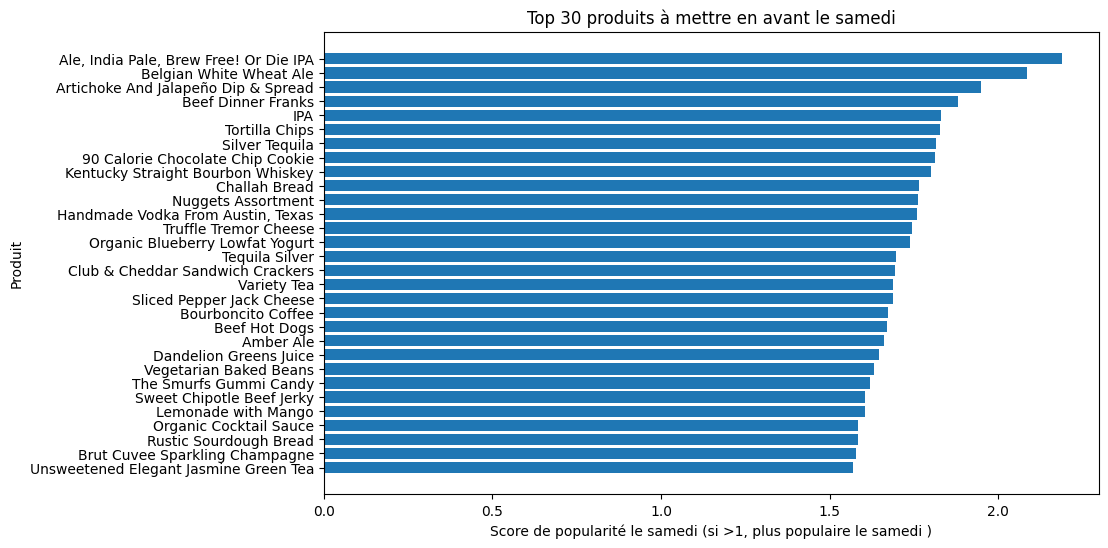

In [152]:
plot_df = (
	analyse_samedi
	.sort_values("saturday_score", ascending=False)
	.head(30)
	.sort_values("saturday_score", ascending=True)
)

plot_df.head()
plt.figure(figsize=(10, 6))
plt.barh(plot_df["product_name"], plot_df["saturday_score"])
plt.xlabel("Score de popularité le samedi (si >1, plus populaire le samedi )")
plt.ylabel("Produit")
plt.title(f"Top 30 produits à mettre en avant le samedi")

plt.show()

## Effet du nombre de commandes sur le réachat
Cette analyse observe à partir de quel moment les clients commencent à racheter plus régulièrement les mêmes produits.

À partir de quelle commande (order_number) les clients commencent-ils à racheter (reordered) de façon significative ?

In [153]:
command_reorder = (
    clean_df    
    .groupby(["order_number"])["reordered"]
    .mean()
    .reset_index(name="reorder_rate")
    .sort_values("order_number")
  
) 

command_reorder


,order_number,reorder_rate
0,1,0.000000
1,2,0.272882
2,3,0.386782
3,4,0.457008
4,5,0.506365
...,...,...
94,95,0.854327
95,96,0.842035
96,97,0.859878
97,98,0.852660


## Visualisation des résultats
Cette cellule génère le graphique associé à l’analyse précédente afin de faciliter l’interprétation des résultats.

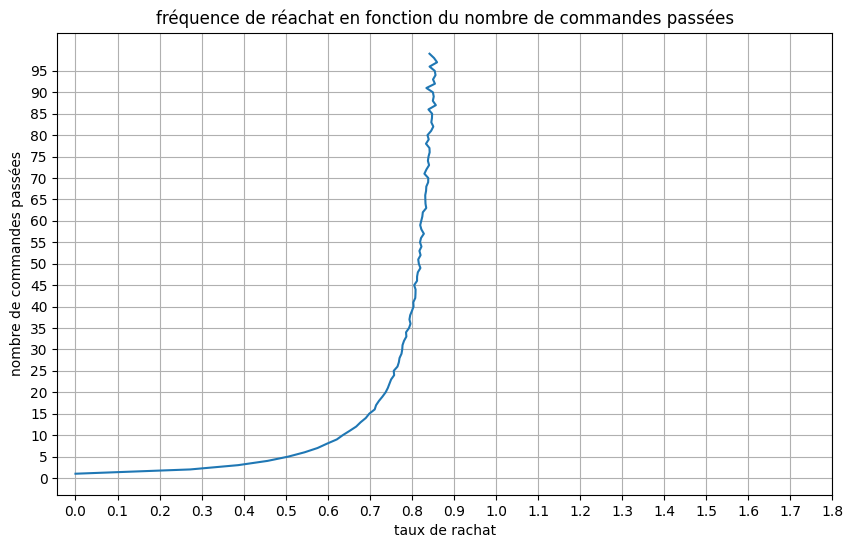

In [154]:
fig, ax = plt.subplots(figsize=(10, 6))

x = command_reorder["reorder_rate"]
y = command_reorder["order_number"]

ax.plot(x, y)

ax.set(xlabel='taux de rachat', ylabel='nombre de commandes passées',
       title='fréquence de réachat en fonction du nombre de commandes passées')
ax.grid()

ax.set_yticks(np.arange(0, y.max() + 1, 5))
ax.set_xticks(np.arange(0, x.max() + 1, 0.1))

plt.show()


# Modélisation

Section Machine Learning : l'objectif ici va être de réaliser une prédiction grâce à un modèle entrainé sur nos données afin de répondre à la question suivante :

Peut-on prédire le taux de chance de reorder d'un produit par un user ? 

## Préparation de l’environnement

Dans cette partie, nous chargeons les outils nécessaires au machine learning ainsi que le jeu de données final.

L’objectif est de préparer un cadre propre pour entraîner et comparer plusieurs modèles de prédiction.

In [155]:
import numpy as np
import pandas as pd

# Split "anti-leakage" (par utilisateur)
from sklearn.model_selection import GroupShuffleSplit

# Preprocessing + pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

# Métriques (classification)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

SEED = 42
np.random.seed(SEED)

df = clean_df

On importe les bibliothèques nécessaires pour la modélisation (pandas/numpy, scikit-learn).

On utilisera un split par utilisateur (GroupShuffleSplit) pour éviter le leakage, ainsi que des pipelines (Pipeline) pour regrouper prétraitement et modèle.

Enfin, on fixe une seed pour rendre les résultats reproductibles.

## Vérification rapide des données

Nous regardons ici la taille du jeu de données, un aperçu des premières lignes et les colonnes disponibles.

Cela permet de confirmer que le fichier a bien été chargé et que les informations utiles à la prédiction sont bien présentes.

In [156]:
print("shape:", df.shape)
display(df.head(3))

print("\nNombre de colonnes:", df.shape[1])
print("Noms des colonnes:", df.columns.tolist()[:30], "...")

shape: (13690540, 18)


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department,user_total_orders,user_product_purchase_count,product_reorder_rate,order_size
0,2,33120,1,1,202279,3,5,9,8,Organic Egg Whites,86.0,16.0,eggs,dairy eggs,7,0,0.706693,9
1,2,28985,2,1,202279,3,5,9,8,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce,7,0,0.696159,9
2,2,9327,3,0,202279,3,5,9,8,Garlic Powder,104.0,13.0,spices seasonings,pantry,7,0,0.152273,9



Nombre de colonnes: 18
Noms des colonnes: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'user_total_orders', 'user_product_purchase_count', 'product_reorder_rate', 'order_size'] ...


## Définition de la cible et séparation des données

Ici, nous définissons ce que le modèle doit prédire : savoir si un produit sera racheté ou non (`reordered`).

Nous séparons ensuite les données en deux groupes :
- un groupe pour entraîner le modèle,
- un groupe pour le tester.

La séparation est faite par utilisateur afin d’éviter qu’un même client apparaisse dans les deux groupes, ce qui fausserait les résultats (leakage).

In [157]:
target = "reordered"
y = df[target].astype(int)

features = [
    "user_id", "product_id", "order_id",
    "order_number", "order_dow", "order_hour_of_day",
    "add_to_cart_order"
]
X = df[features].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, valid_idx = next(gss.split(X, y, groups=X["user_id"]))

train_base = X.iloc[train_idx].copy()
valid_base = X.iloc[valid_idx].copy()
y_train = y.iloc[train_idx].copy()
y_valid = y.iloc[valid_idx].copy()

train_base.shape, valid_base.shape

((10976076, 7), (2714464, 7))

## Création de variables explicatives

Ce bloc transforme les données brutes en informations plus utiles pour le modèle.

Nous résumons le comportement d’achat à trois niveaux :
- **utilisateur** : habitudes et volume d’achat,
- **produit** : popularité et fréquence d’achat,
- **utilisateur + produit** : relation entre un client et un produit précis.

Le but est d’aider le modèle à mieux comprendre les habitudes de consommation.

In [158]:
# USER features
user_feats = train_base.groupby("user_id").agg(
    user_total_lines=("order_id", "size"),
    user_unique_orders=("order_id", "nunique"),
    user_unique_products=("product_id", "nunique"),
    user_max_order_number=("order_number", "max"),
    user_mean_cart_pos=("add_to_cart_order", "mean"),
    user_pref_hour=("order_hour_of_day", "mean"),
    user_pref_dow=("order_dow", "mean"),
).reset_index()

# PRODUCT features
product_feats = train_base.groupby("product_id").agg(
    prod_total_lines=("order_id", "size"),
    prod_unique_users=("user_id", "nunique"),
    prod_unique_orders=("order_id", "nunique"),
    prod_mean_cart_pos=("add_to_cart_order", "mean"),
).reset_index()

# USER x PRODUCT features
up_feats = train_base.groupby(["user_id", "product_id"]).agg(
    up_times_bought=("order_id", "size"),
    up_last_order_number=("order_number", "max"),
    up_first_order_number=("order_number", "min"),
    up_mean_cart_pos=("add_to_cart_order", "mean"),
).reset_index()

up_feats = up_feats.merge(
    user_feats[["user_id", "user_max_order_number"]],
    on="user_id",
    how="left"
)
up_feats["up_recency_orders"] = up_feats["user_max_order_number"] - up_feats["up_last_order_number"]
up_feats = up_feats.drop(columns=["user_max_order_number"])

user_feats.head(), product_feats.head(), up_feats.head()

(   user_id  user_total_lines  user_unique_orders  user_unique_products  \
 0        1                44                   7                    18   
 1        2                29                   2                    28   
 2        3                31                   4                    23   
 3        4                12                   3                    12   
 4        6                11                   2                     9   
 
    user_max_order_number  user_mean_cart_pos  user_pref_hour  user_pref_dow  
 0                     10            3.818182       10.568182       3.113636  
 1                     14            7.827586       10.448276       2.551724  
 2                     10            4.741935       17.548387       1.774194  
 3                      5            3.083333       13.833333       4.250000  
 4                      2            3.454545       16.727273       4.363636  ,
    product_id  prod_total_lines  prod_unique_users  prod_unique_orders  

## Ajout des nouvelles informations aux jeux de données

Les variables créées ci-dessus sont maintenant rattachées aux deux parties destinées aux modèles : entrainement et validation.

Autrement dit, on enrichit chaque achat avec davantage de contexte pour rendre la prédiction plus pertinente.

In [159]:
def attach_features(base_df):
    X = base_df.copy()
    X = X.merge(user_feats, on="user_id", how="left")
    X = X.merge(product_feats, on="product_id", how="left")
    X = X.merge(up_feats, on=["user_id", "product_id"], how="left")
    return X

X_train_full = attach_features(train_base)
X_valid_full = attach_features(valid_base)

X_train_full.shape, X_valid_full.shape

((10976076, 23), (2714464, 23))

## Nettoyage des variables pour le modèle

Certaines colonnes sont retirées avant l’entraînement, notamment les identifiants techniques comme l’utilisateur, le produit ou la commande.

Ces colonnes servent à identifier une ligne, mais elles n’aident pas réellement le modèle à généraliser sur de nouveaux cas.

Lors de la validation, certaines valeurs peuvent être manquantes (NaN) si un utilisateur, un produit ou une paire utilisateur/produit n’a jamais été observé(e) dans l’ensemble d’entraînement. Ces NaN sont attendus et seront ensuite traités par imputation dans le pipeline de machine learning.

Enfin, on supprime les identifiants (user_id, product_id, order_id) car ce ne sont pas des variables « généralisables » : l’objectif est que le modèle apprenne des schémas comportementaux plutôt que de mémoriser des IDs.

In [160]:
drop_cols = ["user_id", "product_id", "order_id"]

X_train_model = X_train_full.drop(columns=drop_cols)
X_valid_model = X_valid_full.drop(columns=drop_cols)

X_train_model.head()

,order_number,order_dow,order_hour_of_day,add_to_cart_order,user_total_lines,user_unique_orders,user_unique_products,user_max_order_number,user_mean_cart_pos,user_pref_hour,user_pref_dow,prod_total_lines,prod_unique_users,prod_unique_orders,prod_mean_cart_pos,up_times_bought,up_last_order_number,up_first_order_number,up_mean_cart_pos,up_recency_orders
0,3,5,9,1,47,4,32,7,6.787234,11.744681,3.553191,6496,2909,6496,6.802186,3,5,1,2.333333,2
1,3,5,9,2,47,4,32,7,6.787234,11.744681,3.553191,22668,10585,22668,7.430783,3,5,1,2.666667,2
2,3,5,9,3,47,4,32,7,6.787234,11.744681,3.553191,2121,1931,2121,9.816124,1,3,3,3.000000,4
3,3,5,9,4,47,4,32,7,6.787234,11.744681,3.553191,249,207,249,8.602410,3,7,3,4.666667,0
4,3,5,9,5,47,4,32,7,6.787234,11.744681,3.553191,165,109,165,8.321212,3,7,3,4.666667,0


## Définition des indicateurs de performance

Nous créons ici une fonction qui regroupe les principales métriques d’évaluation du modèle.

Cela permet de comparer facilement plusieurs modèles avec les mêmes critères de mesure.

Pour évaluer, on utilise plusieurs métriques :

- **Accuracy** : proportion de prédictions correctes (peut être trompeuse si reordered=1 est rare).

- **F1-score** : compromis entre precision et recall pour la classe 1 (reorder).

- **ROC-AUC** : capacité globale à classer correctement les 1 au-dessus des 0.

- **PR-AUC (Average Precision)** : très pertinent quand la classe 1 est rare, car il se concentre sur la qualité de détection des reorders.

Dans un dataset déséquilibré, on s’appuie donc davantage sur F1 et PR-AUC que sur l’accuracy seule.

In [161]:
def classification_metrics(y_true, y_pred, y_proba=None):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        "pr_auc": average_precision_score(y_true, y_proba) if y_proba is not None else np.nan,
    }

## Modèle de référence

Avant de tester des modèles plus avancés, nous commençons par un modèle très simple.

Ce modèle sert de point de comparaison minimum : si un vrai modèle ne fait pas mieux que cette base, alors il n’apporte pas de valeur.

In [162]:
baseline = DummyClassifier(strategy="most_frequent", random_state=SEED)
baseline.fit(X_train_model, y_train)

y_pred = baseline.predict(X_valid_model)
y_proba = baseline.predict_proba(X_valid_model)[:, 1]

baseline_scores = classification_metrics(y_valid, y_pred, y_proba)
baseline_scores

{'accuracy': 0.5885821289212161,
 'f1': 0.7410156745511345,
 'roc_auc': 0.5,
 'pr_auc': 0.5885821289212161}

## Premier modèle : régression logistique

Nous testons ici un premier modèle de classification classique.

Avant l’apprentissage :
- les valeurs manquantes sont remplacées,
- les variables sont mises à l’échelle.

Ce modèle est simple, rapide et constitue une bonne première base pour évaluer la faisabilité de la prédiction.

In [163]:
logreg_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_pipe.fit(X_train_model, y_train)

y_pred = logreg_pipe.predict(X_valid_model)
y_proba = logreg_pipe.predict_proba(X_valid_model)[:, 1]

logreg_scores = classification_metrics(y_valid, y_pred, y_proba)
logreg_scores

{'accuracy': 0.6957690358022799,
 'f1': 0.7552216190709362,
 'roc_auc': 0.7300240398434921,
 'pr_auc': 0.7419629303665067}

## Deuxième modèle : Gradient Boosting

Nous testons ensuite un modèle plus avancé, capable de repérer des relations plus complexes dans les données.

L’idée est de vérifier si un modèle non linéaire peut mieux capter les comportements d’achat qu’un modèle plus simple.

In [164]:
hgb_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(random_state=SEED))
])

hgb_pipe.fit(X_train_model, y_train)

y_pred = hgb_pipe.predict(X_valid_model)
y_proba = hgb_pipe.predict_proba(X_valid_model)[:, 1]

hgb_scores = classification_metrics(y_valid, y_pred, y_proba)
hgb_scores

{'accuracy': 0.6961676411991465,
 'f1': 0.7553447929094836,
 'roc_auc': 0.7498482718867028,
 'pr_auc': 0.7737701770337484}

## Comparaison des modèles

Nous rassemblons ici les résultats des différents modèles dans un tableau comparatif.

Cela permet d’identifier rapidement lequel est le plus performant selon les indicateurs choisis.

In [165]:
results = pd.DataFrame([
    {"model": "Baseline", **baseline_scores},
    {"model": "LogReg", **logreg_scores},
    {"model": "HGB", **hgb_scores},
]).sort_values(by="pr_auc", ascending=False)

results

,model,accuracy,f1,roc_auc,pr_auc
2,HGB,0.696168,0.755345,0.749848,0.773770
1,LogReg,0.695769,0.755222,0.730024,0.741963
0,Baseline,0.588582,0.741016,0.500000,0.588582


## Sélection du meilleur modèle

Le meilleur modèle est choisi automatiquement à partir du tableau de résultats.

Le but est de retenir celui qui offre les performances les plus intéressantes pour notre problématique.

In [166]:
best_model_name = results.iloc[0]["model"]
best_model_name

'HGB'

## Récupération du modèle final

Une fois le meilleur modèle identifié, nous le stockons dans une variable unique.

Cela permet de simplifier la suite de l’analyse et d’utiliser un seul modèle final pour l’évaluation détaillée.

In [167]:
if best_model_name == "LogReg":
    best_pipe = logreg_pipe
elif best_model_name == "HGB":
    best_pipe = hgb_pipe
else:
    best_pipe = baseline
best_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## Évaluation détaillée du modèle retenu

Nous analysons ici plus précisément les performances du meilleur modèle.

La matrice de confusion et le rapport de classification permettent de voir :
- les bonnes prédictions,
- les erreurs,
- la capacité du modèle à repérer les produits susceptibles d’être rachetés.

In [168]:
y_pred_best = best_pipe.predict(X_valid_model)

print("Best model:", best_model_name)
print("\nConfusion matrix:")
print(confusion_matrix(y_valid, y_pred_best))

print("\nClassification report:")
print(classification_report(y_valid, y_pred_best, digits=3))

Best model: HGB

Confusion matrix:
[[ 616574  500205]
 [ 324537 1273148]]

Classification report:
              precision    recall  f1-score   support

           0      0.655     0.552     0.599   1116779
           1      0.718     0.797     0.755   1597685

    accuracy                          0.696   2714464
   macro avg      0.687     0.674     0.677   2714464
weighted avg      0.692     0.696     0.691   2714464



## Lecture métier des erreurs du modèle

Ce dernier bloc détaille les différents types d’erreurs du modèle.

Cela permet de comprendre concrètement l’impact métier :
- recommander un produit inutilement,
- ou au contraire ne pas recommander un produit qui aurait dû l’être.

In [169]:
cm = confusion_matrix(y_valid, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print("TN (vrai 0):", tn)
print("FP (faux 1):", fp, "-> on recommande à tort")
print("FN (faux 0):", fn, "-> on rate un reorder")
print("TP (vrai 1):", tp)

TN (vrai 0): 616574
FP (faux 1): 500205 -> on recommande à tort
FN (faux 0): 324537 -> on rate un reorder
TP (vrai 1): 1273148


## Conclusion sur la modélisation

Dans cet exercice, plusieurs modèles ont été testés pour prédire si un produit sera racheté ou non. Le meilleur résultat a été obtenu avec le modèle **HGB (HistGradientBoostingClassifier)**, qui est un modèle capable de détecter des relations plus complexes dans les données qu’un modèle linéaire classique.

Les performances globales sont correctes pour ce type de problème :
- **accuracy** : 0.696
- **f1-score classe 1** : 0.755
- **precision classe 1** : 0.718
- **recall classe 1** : 0.797

Cela signifie que le modèle est globalement capable d’identifier les produits qui ont de bonnes chances d’être rachetés. Le **recall de 79.7 %** sur la classe 1 est particulièrement intéressant, car cela montre que le modèle retrouve une grande partie des vrais reorders.

La matrice de confusion permet de mieux comprendre le comportement du modèle :
- **616574 vrais négatifs** : le modèle a correctement identifié des produits qui ne seraient pas rachetés
- **1273148 vrais positifs** : le modèle a correctement identifié des produits qui seraient rachetés
- **500205 faux positifs** : le modèle recommande parfois un produit à tort
- **324537 faux négatifs** : le modèle manque parfois un produit qui aurait dû être recommandé

D’un point de vue métier, cela veut dire que le modèle est plutôt efficace pour repérer les produits à recommander de nouveau, mais qu’il reste imparfait :
- il peut parfois proposer des produits inutilement,
- et il peut aussi passer à côté de certains reorders réels.

En résumé, le modèle retenu fournit une **base solide et exploitable** pour un système de recommandation orienté réachat. Les résultats montrent que l’historique d’achat contient suffisamment d’information pour anticiper une partie importante des comportements futurs des utilisateurs.

## Visualisation des prédictions du modèle

Pour rendre les résultats plus concrets, nous ajoutons ici quelques visualisations.

L’objectif est de voir :
- combien de prédictions sont correctes ou incorrectes,
- avec quel niveau de confiance le modèle prédit un réachat,
- et quelques exemples concrets de prédictions comparées à la réalité.

Ces graphiques permettent de mieux comprendre le comportement du modèle, même sans connaissance technique approfondie.

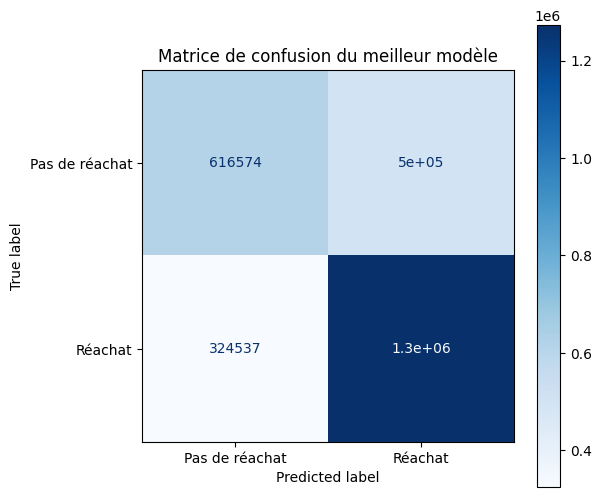

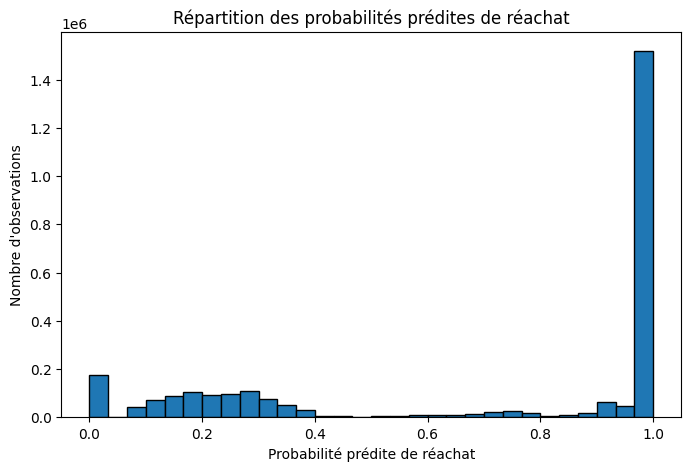

,Valeur réelle,Valeur prédite,Probabilité de réachat
185279,1,1,0.999882
1772127,0,1,0.999263
480988,1,1,0.998619
1792087,1,1,0.990318
578161,1,1,0.585425
1556091,0,0,0.303211
2583611,1,0,0.294628
1450391,0,0,0.262148
930118,0,0,0.000395
863556,0,0,0.000381


In [171]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_pipe.predict(X_valid_model)

if hasattr(best_pipe, "predict_proba"):
    y_proba_best = best_pipe.predict_proba(X_valid_model)[:, 1]
else:
    y_proba_best = best_pipe.decision_function(X_valid_model)

# 1. Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred_best,
    display_labels=["Pas de réachat", "Réachat"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Matrice de confusion du meilleur modèle")
plt.show()

# 2. Distribution des probabilités prédites
plt.figure(figsize=(8, 5))
plt.hist(y_proba_best, bins=30, edgecolor="black")
plt.title("Répartition des probabilités prédites de réachat")
plt.xlabel("Probabilité prédite de réachat")
plt.ylabel("Nombre d'observations")
plt.show()

# 3. Exemples concrets de prédictions
predictions_df = pd.DataFrame({
    "Valeur réelle": y_valid.reset_index(drop=True),
    "Valeur prédite": pd.Series(y_pred_best).reset_index(drop=True),
    "Probabilité de réachat": pd.Series(y_proba_best).reset_index(drop=True)
})

display(predictions_df.sample(10, random_state=42).sort_values("Probabilité de réachat", ascending=False))

## Interprétation des visualisations

La matrice de confusion permet d’identifier rapidement les prédictions correctes et les erreurs du modèle.

L’histogramme des probabilités montre comment le modèle répartit son niveau de confiance : plus les valeurs sont proches de 1, plus le modèle estime qu’un produit sera racheté.

Enfin, le tableau d’exemples permet d’observer des cas concrets de prédiction et de comparer directement la décision du modèle avec la réalité.